# December 2019: SMEs Survey

This analysis examines small and medium enterprise survey data from Algeria, focusing on business characteristics, income sources, skills, social media usage, community challenges, and work roles.

Number of responses: 4709 to approximately ~35 questions

In [160]:
import pandas as pd

In [161]:
df = pd.read_csv('../../data/business_survey_msme/FoB Survey microdata (waves 1-12)/fob_winter_2019/fob_1219_data_weighted_oeclean_update.csv',  encoding='latin-1')
codebook = pd.read_excel('../../data/business_survey_msme/FoB Survey microdata (waves 1-12)/fob_winter_2019/h22019_codebook.xlsx')

In [162]:
df = df[df['logged_iso3']=='DZA']
df.shape

(4709, 160)

In [163]:
# Standardize codebook column names to match other notebooks
rename_map = {
    'Column': 'col_name',
    'Question': 'question_text',
    'Type of response': 'question_type',
    'Possible Values': 'question_options',
    'var': 'col_name',
    'question': 'question_text',
    'type_of_response': 'question_type',
    'possible_values': 'question_options'
}

existing_rename = {k: v for k, v in rename_map.items() if k in codebook.columns}
codebook = codebook.rename(columns=existing_rename)

missing_cols = [col for col in ['col_name', 'question_text', 'question_type', 'question_options'] if col not in codebook.columns]
if missing_cols:
    print(f"Warning: missing expected codebook columns: {missing_cols}")

codebook.head(10)

,col_name,question_text,records,question_type,question_options
0,logged_ds,DATE OF SURVEY ANSWER,216207,TEXT,DATE
1,logged_response_id,RANDOM ID NUMBER,216207,TEXT,RANDOM NUMBER
2,logged_time_started,TIME SURVEY STARTED,216207,TEXT,TIME
3,logged_time_modified,TIME SURVEY LAST MODIFIED (NOT NECESSARILY END),216207,TEXT,TIME
4,logged_finished,REACHED LOGICAL END TO SURVEY FLOW,216207,TEXT,"0,1"
5,logged_locale,SURVEY LANGUAGE CODE,216207,TEXT,LANGUAGE
6,logged_iso2,ISO2 COUNTRY CODE,216207,TEXT,ISO2 CODE
7,age_text,How old are you?,142252,TEXT,"18,75 or older"
8,bus_cdt_text,"At this time, does this business have a line o...",30490,TEXT,"NA,No,I'm not sure,Yes"
9,bus_cdt_numeric,"At this time, does this business have a line o...",30490,NUMERIC,"NA,2,1,3"


In [164]:
# Categorize questions into groups (based on actual 2019 dataset questions)
demographic = [
    'How old are you?',
    'What is your gender?',
    'What is your highest level of completed education?',
    'Do you have a long-term partner or a spouse?',
    'Do you earn the most money among people in your household?',
    'How many people live in your household (including yourself)?',
    'How many children 18 years or younger live in your household?'
]

business_description = [
    'How many employees does this business have? Please include full-time, part-time, temporary, unpaid, and family members working for this business.',
    'How many of these employees are female?',
    'Who owns this business?',
    'How many of the owners of this business are female?',
    'Why did you start or join this business? Please select the main reason..',
    'Did you start or found this business?',
    'Which of these best describe the area you live in?',
    'In which sector is your main job?',
    'In which industry is your main job?'
]

income = [
    'At this time, does this business have a line of credit or a loan from a financial institution or bank?',
    'What is the amount currently owed from all loans that you have taken out for your business at this time (in {currency_symbol})? If there are no such loans please enter zero below.',
    'What was the main source of funds for starting this business?',
    'Which of these describe the household savings or assets used to start this business?',
    'What was the total income for your household over the last month (in {currency_symbol})?   Please enter a number and not words or a range of numbers.',
    'To the best of your knowledge, In a typical month, what are the profits to the owner(s) of this business (in {currency_symbol})?  Please enter only a single number',
    'How do you think your business profits will change in the next 12 months?'
]

skills = [
    'How well do the following statements describe you?',
    'How many years of experience do you have working in business?'
]

social_media = [
    'How does using social media (like Facebook, Instagram, or WhatsApp) affect this business?'
]

community = [
    'In your main business\'s industry and sector, do you think more businesses are owned by men or by women?',
    'A role model is a person who serves as an example. Did you have any key role model growing up?'
]

work_roles = [
    'Which of these best describe your main employment situation?',
    'Which of these best describes your spouse or long-term partner\'s main employment situation?',
    'Are these assets owned by both you and your spouse or long-term partner together?'
]

print("Categories defined:")
print(f"  Demographic: {len(demographic)} questions")
print(f"  Business Description: {len(business_description)} questions")
print(f"  Income: {len(income)} questions")
print(f"  Skills: {len(skills)} questions")
print(f"  Social Media: {len(social_media)} questions")
print(f"  Community: {len(community)} questions")
print(f"  Work Roles: {len(work_roles)} questions")

Categories defined:
  Demographic: 7 questions
  Business Description: 9 questions
  Income: 7 questions
  Skills: 2 questions
  Social Media: 1 questions
  Community: 2 questions
  Work Roles: 3 questions


In [266]:
# Get variable names for each category
import numpy as np

def get_variables_for_questions(question_list, codebook):
    """Get variable names corresponding to questions"""
    variables = []
    for question in question_list:
        if not np.isscalar(question):
            continue
        if pd.isna(question):
            continue
        var = codebook[codebook['question_text'] == question]['col_name'].unique()
        if len(var) > 0:
            variables.extend(var.tolist())
    return variables


demographic_vars = get_variables_for_questions(demographic, codebook)
business_description_vars = get_variables_for_questions(business_description, codebook)
income_vars = get_variables_for_questions(income, codebook)
skills_vars = get_variables_for_questions(skills, codebook)
social_media_vars = get_variables_for_questions(social_media, codebook)
community_vars = get_variables_for_questions(community, codebook)
work_roles_vars = get_variables_for_questions(work_roles, codebook)

print("Variable lists:")
print(f"  demographic_vars ({len(demographic_vars)}): {demographic_vars}")
print(f"  business_description_vars ({len(business_description_vars)}): {business_description_vars[:5]}...")
print(f"  income_vars ({len(income_vars)}): {income_vars}")
print(f"  skills_vars ({len(skills_vars)}): {skills_vars}")
print(f"  social_media_vars ({len(social_media_vars)}): {social_media_vars}")
print(f"  community_vars ({len(community_vars)}): {community_vars}")
print(f"  work_roles_vars ({len(work_roles_vars)}): {work_roles_vars[:5]}...")

Variable lists:
  demographic_vars (94): ['age_text', 'age_numeric_27.0', 'age_numeric_33.0', 'age_numeric_28.0', 'age_numeric_47.0', 'age_numeric_39.0', 'age_numeric_40.0', 'age_numeric_22.0', 'age_numeric_24.0', 'age_numeric_34.0', 'age_numeric_49.0', 'age_numeric_30.0', 'age_numeric_35.0', 'age_numeric_26.0', 'age_numeric_50.0', 'age_numeric_37.0', 'age_numeric_32.0', 'age_numeric_42.0', 'age_numeric_29.0', 'age_numeric_36.0', 'age_numeric_41.0', 'age_numeric_44.0', 'age_numeric_61.0', 'age_numeric_25.0', 'age_numeric_38.0', 'age_numeric_43.0', 'age_numeric_48.0', 'age_numeric_55.0', 'age_numeric_21.0', 'age_numeric_45.0', 'age_numeric_68.0', 'age_numeric_23.0', 'age_numeric_20.0', 'age_numeric_31.0', 'age_numeric_64.0', 'age_numeric_54.0', 'age_numeric_57.0', 'age_numeric_59.0', 'age_numeric_18.0', 'age_numeric_66.0', 'age_numeric_52.0', 'age_numeric_58.0', 'age_numeric_72.0', 'age_numeric_19.0', 'age_numeric_46.0', 'age_numeric_51.0', 'age_numeric_13.0', 'age_numeric_75.0', 'age_n

In [166]:
# Use weight_trim as our weight column (equivalent to weight_trim_final in the other notebook)
df['weight_trim_final'] = df['weight_trim']
print(f"Weight column set up: {df['weight_trim_final'].notna().sum()} non-null values")

Weight column set up: 4709 non-null values


In [167]:
# Create category_vars dictionary for plotting
category_vars = {
    'demographic_vars': demographic_vars,
    'business_description_vars': business_description_vars,
    'income_vars': income_vars,
    'skills_vars': skills_vars,
    'social_media_vars': social_media_vars,
    'community_vars': community_vars,
    'work_roles_vars': work_roles_vars
}

# Create log variables (identifier columns)
candidate_log_vars = ['ds', 'response_id', 'country', 'logged_ds', 'logged_response_id', 'logged_iso2']
log_variables = [c for c in candidate_log_vars if c in df.columns]
print(f"Log variables: {log_variables}")

Log variables: ['logged_ds', 'logged_response_id', 'logged_iso2']


In [168]:
# Analyze numeric and text columns
numeric_cols = 0
numeric_col_names = []
text_col_names = []
text_cols = 0
for cname in df.columns:
    if 'numeric' in cname:
        numeric_cols += 1
        numeric_col_names.append(cname)
    elif 'text' in cname:
        text_cols += 1
        text_col_names.append(cname)

print(f"Numeric columns: {numeric_cols}")
print(f"Text columns: {text_cols}")
print(f"\nSample numeric columns: {numeric_col_names[:10]}")
print(f"Sample text columns: {text_col_names[:10]}")

Numeric columns: 50
Text columns: 55

Sample numeric columns: ['bus_cdt_numeric', 'chl_numeric', 'edu_numeric', 'bus_emp_numeric', 'bus_exp_numeric', 'bus_fem_numeric', 'bus_fnd_1a_numeric', 'bus_fnd_1c_numeric', 'bus_fnd_2a_numeric', 'bus_fnd_2d_numeric']
Sample text columns: ['age_text', 'bus_cdt_text', 'chl_text', 'edu_text', 'bus_emp_text', 'bus_exp_text', 'bus_fem_text', 'bus_fnd_1a_text', 'bus_fnd_1c_text', 'bus_fnd_2a_text']


In [169]:
# Get all survey variables to aggregate
all_survey_vars = (demographic_vars + business_description_vars + income_vars + 
                   skills_vars + social_media_vars + community_vars + work_roles_vars)

# Find all _text columns for processing
text_vars_to_process = [v for v in all_survey_vars if v.endswith('_text') and '_text_' not in v and v in df.columns]

print(f"Total survey variables: {len(all_survey_vars)}")
print(f"Text variables to process: {len(text_vars_to_process)}")
print(f"Sample text vars: {text_vars_to_process[:10]}")

Total survey variables: 89
Text variables to process: 38
Sample text vars: ['age_text', 'sex_text', 'edu_text', 'mar_text', 'hhs_text', 'hhn_text', 'chl_text', 'bus_emp_text', 'own_fem_text', 'bus_mot_text']


In [170]:
# Create indicator columns for single-select (radio) questions
# This makes radio questions consistent with multi-select questions structure
import json
import re
import numpy as np

print(f"Processing text variables to create indicator columns...")

# Collect all new columns in a dictionary to avoid DataFrame fragmentation
new_columns = {}
# Track columns to drop and codebook entries to add
cols_to_drop = []
new_codebook_rows = []

for var in text_vars_to_process:
    base_name = var.replace('_text', '')
    
    # Check if this already has multi-select structure (multiple _text_ or _numeric_ columns)
    multi_select_cols = [col for col in df.columns if col.startswith(f"{base_name}_text_") or col.startswith(f"{base_name}_numeric_")]
    
    if len(multi_select_cols) > 0:
        # Already has multi-select/indicator structure, skip
        continue
    
    # Check if this is a single-select question that needs indicator columns
    question_row = codebook[codebook['col_name'] == var]
    if len(question_row) == 0:
        continue
    
    question_text = question_row['question_text'].iloc[0]
    
    # Get unique responses from the text column
    unique_responses = df[var].dropna().unique()
    
    if len(unique_responses) == 0:
        continue
    
    # Mark the original numeric column for removal to avoid double counting
    original_numeric_col = f"{base_name}_numeric"
    if original_numeric_col in df.columns:
        cols_to_drop.append(original_numeric_col)
    
    # Create indicator column for each response option
    for response in unique_responses:
        response_clean = str(response).strip()
        if not response_clean:
            continue
            
        # Create column name: base_numeric_responsename
        col_name_safe = response_clean.lower().replace(' ', '_').replace('-', '_').replace('(', '').replace(')', '').replace(',', '').replace("'", '').replace('/', '_')
        new_col_name = f"{base_name}_numeric_{col_name_safe}"
        
        # Create indicator: 1 if matches, 0 if doesn't, NaN if original was NaN
        new_columns[new_col_name] = df[var].apply(lambda x: 1.0 if pd.notna(x) and str(x).strip() == response_clean else (0.0 if pd.notna(x) else np.nan)).astype('float64')
        
        # Add codebook entry for this new column
        new_codebook_rows.append({
            'col_name': new_col_name,
            'question_text': question_text,
            'question_type': 'numeric',
            'question_options': pd.NA
        })
    
    print(f"  Created {len(unique_responses)} indicator columns for {var}")

# Add all new columns at once using pd.concat to avoid fragmentation
if new_columns:
    df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)
    print(f"\nAdded {len(new_columns)} indicator columns to dataframe")

# Drop original numeric columns to avoid double counting
if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f"Dropped {len(cols_to_drop)} original numeric columns to avoid double counting")

# Add new codebook entries
if new_codebook_rows:
    new_codebook_df = pd.DataFrame(new_codebook_rows)
    codebook = pd.concat([codebook, new_codebook_df], ignore_index=True)
    print(f"Added {len(new_codebook_rows)} entries to codebook")

print("\nIndicator column creation complete!")

Processing text variables to create indicator columns...
  Created 58 indicator columns for age_text
  Created 2 indicator columns for sex_text
  Created 5 indicator columns for edu_text
  Created 2 indicator columns for mar_text
  Created 2 indicator columns for hhs_text
  Created 6 indicator columns for hhn_text
  Created 6 indicator columns for chl_text
  Created 8 indicator columns for bus_emp_text
  Created 4 indicator columns for own_fem_text
  Created 6 indicator columns for bus_mot_text
  Created 11 indicator columns for bus_str_text
  Created 3 indicator columns for urb_text
  Created 3 indicator columns for sec_agr_text
  Created 5 indicator columns for sec_art_text
  Created 3 indicator columns for sec_fda_text
  Created 4 indicator columns for sec_hea_text
  Created 7 indicator columns for sec_inf_text
  Created 8 indicator columns for sec_man_text
  Created 9 indicator columns for sec_oth_text
  Created 8 indicator columns for sec_ser_text
  Created 3 indicator columns for

In [171]:
# Identify continuous numeric variables that should not be converted to indicators
# These are questions where the response is a numeric value, not a categorical choice
# Also exclude high-cardinality categorical variables (too many unique values for clear charts)
continuous_vars = [
    'bus_emp_text',  # Number of employees
    'bus_fem_text',  # Number of female employees
    'own_fem_text',  # Number of female owners
    'bus_exp_text',  # Years of experience
    'ind_text',      # Industry (too many unique values)
    'sec_agr_text',  # Sector - Agriculture (high cardinality)
    'sec_art_text',  # Sector - Arts (high cardinality)
    'sec_fda_text',  # Sector - Food/Accommodation (high cardinality)
    'sec_hea_text',  # Sector - Health (high cardinality)
    'sec_inf_text',  # Sector - Information (high cardinality)
    'sec_man_text',  # Sector - Manufacturing (high cardinality)
    'sec_oth_text',  # Sector - Other (high cardinality)
    'sec_ser_text',  # Sector - Services (high cardinality)
    'sec_trd_text',  # Sector - Trade (high cardinality)
    'sec_trn_text',  # Sector - Transport (high cardinality)
    # Income continuous variables (will be bucketed later)
    'bus_loa_text',  # Loan amount owed
    'inc_hse_text',  # Household income
    'bus_pft_text',  # Business profits
]

print(f"Continuous variables to exclude from indicator conversion: {len(continuous_vars)}")
print(f"\nOriginal business_description_vars: {len(business_description_vars)}")

# Also need to exclude all numeric indicator columns that were created from these text columns
sector_text_prefixes = ['sec_agr_', 'sec_art_', 'sec_fda_', 'sec_hea_', 
                        'sec_inf_', 'sec_man_', 'sec_oth_', 'sec_ser_', 
                        'sec_trd_', 'sec_trn_']

# Remove continuous vars and all their related indicator columns
business_description_vars_categorical = [
    v for v in business_description_vars 
    if v not in continuous_vars and not any(v.startswith(prefix) for prefix in sector_text_prefixes)
]
skills_vars_categorical = [v for v in skills_vars if v not in continuous_vars]
income_vars_categorical = [v for v in income_vars if v not in continuous_vars]

print(f"Categorical business_description_vars: {len(business_description_vars_categorical)}")
print(f"Categorical skills_vars: {len(skills_vars_categorical)}")
print(f"Categorical income_vars: {len(income_vars_categorical)}")

Continuous variables to exclude from indicator conversion: 18

Original business_description_vars: 32
Categorical business_description_vars: 9
Categorical skills_vars: 15
Categorical income_vars: 15


In [172]:
# Aggregate sector responses into broader categories
print("Aggregating sector responses into broader categories...")

# Map individual sector columns to aggregated categories
sector_aggregation = {
    'sec_agr': 'Agriculture & Natural Resources',
    'sec_art': 'Creative Arts & Entertainment',
    'sec_fda': 'Food & Beverage Services',
    'sec_hea': 'Healthcare',
    'sec_inf': 'Information & Media',
    'sec_man': 'Manufacturing & Production',
    'sec_oth': 'Professional Services & Other',
    'sec_ser': 'Construction & Repair Services',
    'sec_trd': 'Trade',
    'sec_trn': 'Transportation & Logistics'
}

# Create aggregated sector indicator columns
for base_name, category_name in sector_aggregation.items():
    sector_indicator_cols = [col for col in df.columns if col.startswith(f"{base_name}_numeric_")]
    if sector_indicator_cols:
        col_name_safe = category_name.lower().replace(' ', '_').replace('&', 'and').replace(',', '')
        aggregated_col_name = f"sector_aggregated_numeric_{col_name_safe}"
        df[aggregated_col_name] = df[sector_indicator_cols].max(axis=1)
        new_codebook_row = pd.DataFrame([{
            'col_name': aggregated_col_name,
            'question_text': 'In which sector is your main job? (Aggregated)',
            'question_type': 'numeric',
            'question_options': pd.NA
        }])
        codebook = pd.concat([codebook, new_codebook_row], ignore_index=True)
        print(f"  Created {aggregated_col_name} from {len(sector_indicator_cols)} detailed indicators")

print("\nSector aggregation complete!")

Aggregating sector responses into broader categories...
  Created sector_aggregated_numeric_agriculture_and_natural_resources from 3 detailed indicators
  Created sector_aggregated_numeric_creative_arts_and_entertainment from 5 detailed indicators
  Created sector_aggregated_numeric_food_and_beverage_services from 3 detailed indicators
  Created sector_aggregated_numeric_healthcare from 4 detailed indicators
  Created sector_aggregated_numeric_information_and_media from 7 detailed indicators
  Created sector_aggregated_numeric_manufacturing_and_production from 8 detailed indicators
  Created sector_aggregated_numeric_professional_services_and_other from 9 detailed indicators
  Created sector_aggregated_numeric_construction_and_repair_services from 8 detailed indicators
  Created sector_aggregated_numeric_trade from 3 detailed indicators
  Created sector_aggregated_numeric_transportation_and_logistics from 4 detailed indicators

Sector aggregation complete!


In [173]:
# Add aggregated sector columns to business_description_vars
aggregated_sector_cols = [col for col in df.columns if col.startswith('sector_aggregated_numeric_')]
business_description_vars.extend(aggregated_sector_cols)

print(f"Added {len(aggregated_sector_cols)} aggregated sector columns to business_description_vars")
print(f"Updated business_description_vars now has {len(business_description_vars)} variables")

# Also add the detailed sector text columns to continuous_vars so they're excluded from charts
sector_text_vars = [f'sec_{suffix}_text' for suffix in ['agr', 'art', 'fda', 'hea', 'inf', 'man', 'oth', 'ser', 'trd', 'trn']]
continuous_vars.extend(sector_text_vars)

print(f"Added {len(sector_text_vars)} detailed sector columns to continuous_vars (to exclude from charts)")
print(f"Updated continuous_vars: {continuous_vars}")

Added 10 aggregated sector columns to business_description_vars
Updated business_description_vars now has 42 variables
Added 10 detailed sector columns to continuous_vars (to exclude from charts)
Updated continuous_vars: ['bus_emp_text', 'bus_fem_text', 'own_fem_text', 'bus_exp_text', 'ind_text', 'sec_agr_text', 'sec_art_text', 'sec_fda_text', 'sec_hea_text', 'sec_inf_text', 'sec_man_text', 'sec_oth_text', 'sec_ser_text', 'sec_trd_text', 'sec_trn_text', 'bus_loa_text', 'inc_hse_text', 'bus_pft_text', 'sec_agr_text', 'sec_art_text', 'sec_fda_text', 'sec_hea_text', 'sec_inf_text', 'sec_man_text', 'sec_oth_text', 'sec_ser_text', 'sec_trd_text', 'sec_trn_text']


In [174]:
# Update category_vars to use categorical-only lists for charting
category_vars_for_charts = {
    'demographic_vars': demographic_vars,
    'business_description_vars': business_description_vars_categorical,
    'income_vars': income_vars_categorical,
    'skills_vars': skills_vars_categorical,
    'social_media_vars': social_media_vars,
    'community_vars': community_vars,
    'work_roles_vars': work_roles_vars
}

print("Updated category_vars for charts (excluding continuous numeric variables)")

Updated category_vars for charts (excluding continuous numeric variables)


In [175]:
# Update demographic_vars to remove dropped numeric columns and keep only text columns for grouping
demographic_vars_for_grouping = [v for v in demographic_vars if v in df.columns and v.endswith('_text') and '_text_' not in v]
print(f"Demographic variables for grouping (text only): {demographic_vars_for_grouping}")

Demographic variables for grouping (text only): ['age_text', 'sex_text', 'edu_text', 'mar_text', 'hhs_text', 'hhn_text', 'chl_text']


In [176]:
# Calculate weighted values grouped by demographic variables
# Get all numeric columns from our categories
numeric_cols_list = (business_description_vars + income_vars + skills_vars + 
                     social_media_vars + community_vars + work_roles_vars)

# Add indicator columns (those with _numeric_ in the name that aren't base columns)
for var in text_vars_to_process:
    base_name = var.replace('_text', '')
    indicator_cols = [col for col in df.columns if col.startswith(f"{base_name}_numeric_") and col != f"{base_name}_numeric"]
    numeric_cols_list.extend(indicator_cols)

# Filter to only numeric columns that exist in df
numeric_cols_to_agg = [col for col in numeric_cols_list if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]

print(f"Total columns to aggregate: {len(numeric_cols_to_agg)}")
print(f"Sample columns: {numeric_cols_to_agg[:10]}")

Total columns to aggregate: 444
Sample columns: ['sector_aggregated_numeric_agriculture_and_natural_resources', 'sector_aggregated_numeric_creative_arts_and_entertainment', 'sector_aggregated_numeric_food_and_beverage_services', 'sector_aggregated_numeric_healthcare', 'sector_aggregated_numeric_information_and_media', 'sector_aggregated_numeric_manufacturing_and_production', 'sector_aggregated_numeric_professional_services_and_other', 'sector_aggregated_numeric_construction_and_repair_services', 'sector_aggregated_numeric_trade', 'sector_aggregated_numeric_transportation_and_logistics']


In [177]:
# Group by demographics and calculate weighted sums
grouped_weighted = df.groupby(demographic_vars_for_grouping).agg({
    **{col: 'sum' for col in numeric_cols_to_agg},
    'weight_trim_final': 'sum'
}).reset_index()

# Calculate weighted means for all columns at once (avoids DataFrame fragmentation)
weight_col = grouped_weighted['weight_trim_final']
weighted_means = {f'{col}_weighted_mean': grouped_weighted[col] / weight_col for col in numeric_cols_to_agg}
grouped_weighted = pd.concat([grouped_weighted, pd.DataFrame(weighted_means)], axis=1)

print(f"Grouped by {len(demographic_vars_for_grouping)} demographic variables")
print(f"Aggregated {len(numeric_cols_to_agg)} numeric columns")
print(f"Result shape: {grouped_weighted.shape}")
print("\nFirst few rows:")
print(grouped_weighted.head())

Grouped by 7 demographic variables
Aggregated 444 numeric columns
Result shape: (238, 896)

First few rows:
   age_text sex_text                                           edu_text  \
0      18.0     Male  More than secondary, vocational training or ap...   
1      18.0     Male                                            Primary   
2      18.0     Male                              University or college   
3      18.0     Male                              University or college   
4      19.0   Female                              University or college   

  mar_text hhs_text   hhn_text chl_text  \
0       No      Yes          4        2   
1       No       No          5        1   
2       No       No          5        4   
3       No       No  6 or more        3   
4       No       No  6 or more        1   

   sector_aggregated_numeric_agriculture_and_natural_resources  \
0                                                0.0             
1                                                0

In [178]:
# Create separate dataframes for each demographic variable
demographic_dfs = {}

for demo_var in demographic_vars_for_grouping:
    grouped = df.groupby(demo_var).agg({
        **{col: 'sum' for col in numeric_cols_to_agg},
        'weight_trim_final': 'sum'
    }).reset_index()
    
    weight_col = grouped['weight_trim_final']
    weighted_means = {f'{col}_weighted_mean': grouped[col] / weight_col for col in numeric_cols_to_agg}
    grouped = pd.concat([grouped, pd.DataFrame(weighted_means)], axis=1)
    
    demographic_dfs[demo_var] = grouped
    print(f"{demo_var}: {grouped.shape[0]} groups, {grouped.shape[1]} columns")

print(f"\nCreated {len(demographic_dfs)} demographic dataframes")
print(f"Keys: {list(demographic_dfs.keys())}")

age_text: 58 groups, 890 columns
sex_text: 2 groups, 890 columns
edu_text: 5 groups, 890 columns
mar_text: 2 groups, 890 columns
hhs_text: 2 groups, 890 columns
hhn_text: 6 groups, 890 columns
chl_text: 6 groups, 890 columns

Created 7 demographic dataframes
Keys: ['age_text', 'sex_text', 'edu_text', 'mar_text', 'hhs_text', 'hhn_text', 'chl_text']


In [179]:
# Create pre-calculated "All Data" aggregation grouped by log_variables
# Similar structure to demographic_dfs but grouped by response identifiers
all_data_aggregated = df.groupby(log_variables).agg({
    **{col: 'sum' for col in numeric_cols_to_agg},
    'weight_trim_final': 'sum'
}).reset_index()

# Calculate weighted means
weight_col = all_data_aggregated['weight_trim_final']
weighted_means = {f'{col}_weighted_mean': all_data_aggregated[col] / weight_col for col in numeric_cols_to_agg}
all_data_aggregated = pd.concat([all_data_aggregated, pd.DataFrame(weighted_means)], axis=1)

print(f"Pre-calculated 'All Data' aggregation:")
print(f"Grouped by {len(log_variables)} log variables")
print(f"Result shape: {all_data_aggregated.shape}")
print(f"Total respondents: {all_data_aggregated['weight_trim_final'].sum():.1f}")
all_data_aggregated.head()

Pre-calculated 'All Data' aggregation:
Grouped by 3 log variables
Result shape: (4709, 892)
Total respondents: 4709.0


,logged_ds,logged_response_id,logged_iso2,sector_aggregated_numeric_agriculture_and_natural_resources,sector_aggregated_numeric_creative_arts_and_entertainment,sector_aggregated_numeric_food_and_beverage_services,sector_aggregated_numeric_healthcare,sector_aggregated_numeric_information_and_media,sector_aggregated_numeric_manufacturing_and_production,sector_aggregated_numeric_professional_services_and_other,...,bus_rol_spo_numeric_employed_in_a_business_weighted_mean,bus_rol_spo_numeric_unemployed_or_not_working_weighted_mean,bus_rol_spo_numeric_both_own_and_manage_a_business_weighted_mean,bus_rol_spo_numeric_work_for_the_government_weighted_mean,bus_rol_spo_numeric_own_a_business_weighted_mean,bus_rol_spo_numeric_manage_a_business_weighted_mean,bus_rol_spo_numeric_other_please_specify_weighted_mean,bus_fnd_2d_numeric_dont_know_or_prefer_not_to_say_weighted_mean,bus_fnd_2d_numeric_yes_owned_jointly_weighted_mean,bus_fnd_2d_numeric_no_single_ownership_weighted_mean
0,2019-12-07,1.295517e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2019-12-07,1.314266e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2019-12-07,1.332492e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2019-12-07,1.337574e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019-12-07,1.338094e+14,DZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [180]:
# Helper function to get question text from variable name
def get_question_for_variable(var_name, codebook):
    """Get question text for a variable from codebook"""
    if var_name in codebook['col_name'].values:
        question = codebook[codebook['col_name'] == var_name]['question_text'].iloc[0]
        if pd.notna(question):
            return question
    return var_name

# Test the function
print("Testing get_question_for_variable:")
print(f"fob_age_text: {get_question_for_variable('fob_age_text', codebook)}")
print(f"fob_sex_text: {get_question_for_variable('fob_sex_text', codebook)}")

Testing get_question_for_variable:
fob_age_text: fob_age_text
fob_sex_text: fob_sex_text


In [181]:
import altair as alt
from IPython.display import display

# Enable data transformer to handle larger datasets
alt.data_transformers.enable('default', max_rows=None)

print("Altair imported and configured for large datasets")

Altair imported and configured for large datasets


In [315]:
# Create a combined dataset with all categories for interactive filtering
# Prepare data for all categories
all_categories_data = []

for category in ['business_description', 'income', 'skills', 'social_media', 'community', 'work_roles']:
    # Get variable list (using categorical-only lists)
    var_list = category_vars_for_charts[f'{category}_vars']
    
    # Find unique questions
    unique_questions = {}
    for v in var_list:
        if '_text_' in v:
            base_name = v.split('_text_')[0]
            if base_name not in unique_questions:
                unique_questions[base_name] = []
            unique_questions[base_name].append(v)
        elif '_numeric_' in v and not v.endswith('_numeric'):
            base_name = v.split('_numeric_')[0]
            if base_name not in unique_questions:
                unique_questions[base_name] = []
            unique_questions[base_name].append(v)
        elif v.endswith('_text'):
            base_name = v.replace('_text', '')
            if base_name not in unique_questions:
                unique_questions[base_name] = [v]
    
    # Calculate total weight
    total_weight = all_data_aggregated['weight_trim_final'].sum()
    
    # Process each question
    for base_name, question_cols in unique_questions.items():
        first_col = question_cols[0] if question_cols else None
        if not first_col or first_col not in df.columns:
            continue
        
        question_text = get_question_for_variable(first_col, codebook)
        
        # Find numeric columns
        numeric_cols = [col for col in all_data_aggregated.columns
                       if (col.startswith(f"{base_name}_text_") or col.startswith(f"{base_name}_numeric_") or col == f"{base_name}_numeric")
                       and not col.endswith('_weighted_mean')
                       and pd.api.types.is_numeric_dtype(all_data_aggregated[col])]
        
        indicator_cols = [col for col in numeric_cols if (f"{base_name}_text_" in col or f"{base_name}_numeric_" in col) and not col.endswith('_weighted_mean')]
        
        if indicator_cols:
            # Multi-select/radio questions
            for num_col in indicator_cols:
                weighted_sum = all_data_aggregated[num_col].sum()
                if weighted_sum > 0:
                    if f"{base_name}_text_" in num_col:
                        response = num_col.replace(f"{base_name}_text_", "").replace("_", " ").title()
                    else:
                        response = num_col.replace(f"{base_name}_numeric_", "").replace("_", " ").title()
                    percentage = (weighted_sum / total_weight) * 100
                    all_categories_data.append({
                        'category': category.replace('_', ' ').title(),
                        'question': question_text,
                        'response': response,
                        'value': percentage
                    })
        else:
            # Single-select questions without indicator columns
            numeric_col = f"{base_name}_numeric"
            text_col = f"{base_name}_text"
            if text_col in df.columns and numeric_col in all_data_aggregated.columns:
                # Get unique responses from original data
                for response_text in df[text_col].dropna().unique():
                    # Find matching rows and calculate weighted sum
                    mask = df[text_col] == response_text
                    if mask.any():
                        # Sum weighted values for this response
                        weighted_sum = df.loc[mask, numeric_col].sum()
                        if weighted_sum > 0:
                            percentage = (weighted_sum / total_weight) * 100
                            all_categories_data.append({
                                'category': category.replace('_', ' ').title(),
                                'question': question_text,
                                'response': str(response_text),
                                'value': percentage
                            })

# Create DataFrame
combined_df = pd.DataFrame(all_categories_data)

print(f"Total rows in combined_df: {len(combined_df)}")
print(f"Categories: {combined_df['category'].unique()}")
print(f"Questions per category:")
for cat in combined_df['category'].unique():
    n_questions = combined_df[combined_df['category'] == cat]['question'].nunique()
    print(f"  {cat}: {n_questions} questions")

Total rows in combined_df: 192
Categories: ['Business Description' 'Income' 'Skills' 'Social Media' 'Community'
 'Work Roles']
Questions per category:
  Business Description: 3 questions
  Income: 6 questions
  Skills: 1 questions
  Social Media: 1 questions
  Community: 2 questions
  Work Roles: 3 questions


In [316]:
# Filter out non-numeric responses for specific numeric questions
print("\nFiltering out non-numeric responses...")

# Questions that should only have numeric responses
numeric_only_questions = [
    'How many of these employees are female?',
    'How many of the owners of this business are female?',
    'How many years of experience do you have working in business?',
    'What was the total income for your household over the last month (in {currency_symbol})?   Please enter a number and not words or a range of numbers.',
    'To the best of your knowledge, In a typical month, what are the profits to the owner(s) of this business (in {currency_symbol})?  Please enter only a single number',
    'What is the amount currently owed from all loans that you have taken out for your business at this time (in {currency_symbol})? If there are no such loans please enter zero below.'
]

# Apply the numeric-only filter
original_count = len(combined_df)
for question in numeric_only_questions:
    mask = combined_df['question'] == question
    if mask.any():
        numeric_mask = pd.to_numeric(combined_df.loc[mask, 'response'], errors='coerce').notna()
        combined_df = combined_df[~mask | numeric_mask]

filtered_count = len(combined_df)
print(f"Filtered out {original_count - filtered_count} non-numeric responses")
print(f"Remaining responses: {filtered_count}")

# Keep only the 8 official response options for the employee-count question
import re

def normalize_option(value):
    value_str = str(value).strip().lower()
    value_str = re.sub(r'[^a-z0-9]+', '_', value_str)
    return value_str.strip('_')

bus_emp_question = 'How many employees does this business have? Please include full-time, part-time, temporary, unpaid, and family members working for this business.'
bus_emp_col = 'bus_emp_text'

bus_emp_rows = codebook[codebook['col_name'] == bus_emp_col]
bus_emp_mapping = {}
if len(bus_emp_rows) > 0:
    options_raw = str(bus_emp_rows['question_options'].iloc[0])
    for opt in [o.strip() for o in options_raw.split(',')]:
        if not opt or opt.lower() == 'na':
            continue
        bus_emp_mapping[normalize_option(opt)] = opt

if bus_emp_mapping:
    mask = combined_df['question'] == bus_emp_question
    if mask.any():
        combined_df.loc[mask, 'response'] = combined_df.loc[mask, 'response'].apply(
            lambda x: bus_emp_mapping.get(normalize_option(x))
        )
        original_count = mask.sum()
        combined_df = combined_df[~mask | combined_df['response'].notna()]
        filtered_count = (combined_df['question'] == bus_emp_question).sum()
        print(f"Filtered employee-count responses from {original_count} to {filtered_count}")
    else:
        print("Employee-count question not found in combined_df")
else:
    print("No employee-count options found in codebook")


Filtering out non-numeric responses...
Filtered out 36 non-numeric responses
Remaining responses: 156
Employee-count question not found in combined_df


In [317]:
# Filter funding responses to include only official codebook options
print("\nFiltering funding responses to official options...")

funding_question = "What was the main source of funds for starting this business?"
funding_cols = ['bus_fnd_1a_text', 'bus_fnd_2a_text']

funding_rows = codebook[codebook['col_name'].isin(funding_cols)]
official_responses = []
for options in funding_rows['question_options'].dropna():
    for opt in [o.strip() for o in str(options).split(',')]:
        if not opt or opt.lower() == 'na':
            continue
        opt_safe = (
            opt.lower()
            .replace(' ', '_')
            .replace('-', '_')
            .replace('/', '_')
            .replace('(', '')
            .replace(')', '')
            .replace(',', '')
            .replace("'", '')
        )
        opt_display = opt_safe.replace('_', ' ').title()
        official_responses.append(opt_display)

official_responses = sorted(set(official_responses))
print(f"Found {len(official_responses)} official funding responses")

mask = combined_df['question'] == funding_question
if mask.any():
    original_count = mask.sum()
    combined_df = combined_df[~mask | combined_df['response'].isin(official_responses)]
    filtered_count = (combined_df['question'] == funding_question).sum()
    print(f"Filtered funding responses from {original_count} to {filtered_count}")
else:
    print(f"Funding question '{funding_question}' not found in combined_df")


Filtering funding responses to official options...
Found 8 official funding responses
Filtered funding responses from 13 to 13


In [318]:
# Create buckets for numeric responses
print("\nCreating buckets for numeric questions...")

# Define bucket ranges for selected numeric questions
bucket_definitions = {
    'How many of these employees are female?': [
        (0, 0, '0 female employees'),
        (1, 4, '1-4 female employees'),
        (5, 9, '5-9 female employees'),
        (10, 19, '10-19 female employees'),
        (20, float('inf'), '20+ female employees')
    ],
    'How many of the owners of this business are female?': [
        (0, 0, '0 female owners'),
        (1, 1, '1 female owner'),
        (2, 2, '2 female owners'),
        (3, float('inf'), '3+ female owners')
    ],
    'business_profits': {  # Special handling for multi-column questions
        'base_col': 'bus_pft',
        'buckets': [
            (0, 0, '0'),
            (1, 10_000, '1-10,000'),
            (10_001, 50_000, '10,001-50,000'),
            (50_001, 100_000, '50,001-100,000'),
            (100_001, 250_000, '100,001-250,000'),
            (250_001, 500_000, '250,001-500,000'),
            (500_001, 1_000_000, '500,001-1,000,000'),
            (1_000_001, float('inf'), '1,000,001+')
        ]
    },
    'business_loans': {  # Special handling for multi-column questions
        'base_col': 'bus_lon',
        'buckets': [
            (0, 0, '0'),
            (1, 10_000, '1-10,000'),
            (10_001, 50_000, '10,001-50,000'),
            (50_001, 100_000, '50,001-100,000'),
            (100_001, 250_000, '100,001-250,000'),
            (250_001, 500_000, '250,001-500,000'),
            (500_001, 1_000_000, '500,001-1,000,000'),
            (1_000_001, float('inf'), '1,000,001+')
        ]
    },
    'household_income': {  # Special handling for multi-column questions
        'base_col': 'inc_hse',
        'buckets': [
            (0, 0, '0'),
            (1, 20_000, '1-20,000'),
            (20_001, 50_000, '20,001-50,000'),
            (50_001, 100_000, '50,001-100,000'),
            (100_001, 200_000, '100,001-200,000'),
            (200_001, 500_000, '200,001-500,000'),
            (500_001, 1_000_000, '500,001-1,000,000'),
            (1_000_001, float('inf'), '1,000,001+')
        ]
    },
    'business_experience': {  # Special handling for years of experience
        'base_col': 'bus_exp',
        'buckets': [
            (0, 1, 'Less than 1 year'),
            (1, 2, 'Between 1 and 2 years'),
            (2, 5, 'Between 2 and 5 years'),
            (5, float('inf'), '5 years or more')
        ]
    }
}

def get_bucket_label(value, buckets):
    try:
        num_value = float(value)
        for min_val, max_val, label in buckets:
            if min_val <= num_value <= max_val:
                return label
        return None
    except (ValueError, TypeError):
        return None

bucketed_data = []

# First handle single-column text responses with buckets
simple_bucket_questions = {k: v for k, v in bucket_definitions.items() if isinstance(v, list)}

for question, buckets in simple_bucket_questions.items():
    question_normalized = question.replace('{currency_symbol}', '')
    question_data = combined_df[combined_df['question'] == question].copy()
    
    if len(question_data) == 0:
        for q in combined_df['question'].unique():
            if q.replace('{currency_symbol}', '') == question_normalized or q.startswith(question_normalized[:50]):
                question_data = combined_df[combined_df['question'] == q].copy()
                break
    
    if len(question_data) == 0:
        print(f"  ⚠️  Question not found: {question[:60]}...")
        continue

    bucket_aggregation = {}
    for _, row in question_data.iterrows():
        bucket_label = get_bucket_label(row['response'], buckets)
        if bucket_label:
            bucket_aggregation[bucket_label] = bucket_aggregation.get(bucket_label, 0) + row['value']

    category = question_data['category'].iloc[0]
    actual_question = question_data['question'].iloc[0]
    for bucket_label, total_value in bucket_aggregation.items():
        bucketed_data.append({
            'category': category,
            'question': actual_question,
            'response': bucket_label,
            'value': total_value
        })
    print(f"  ✓ Created {len(bucket_aggregation)} buckets for: {question[:60]}...")

# Now handle multi-column numeric questions
multi_col_questions = {k: v for k, v in bucket_definitions.items() if isinstance(v, dict)}

for question_key, config in multi_col_questions.items():
    base_col = config['base_col']
    buckets = config['buckets']
    
    # Find all numeric columns for this base column
    numeric_cols = [col for col in all_data_aggregated.columns 
                   if col.startswith(f"{base_col}_numeric_") and not col.endswith('_weighted_mean')]
    
    if not numeric_cols:
        print(f"  ⚠️  No numeric columns found for {question_key}")
        continue
    
    # Extract the actual values from column names and aggregate by bucket
    bucket_aggregation = {}
    
    # Check if this is an indicator column (like experience) or value column (like profits/loans)
    # Indicator columns have labels in the name, value columns have numbers
    is_indicator = False
    if 'bus_exp' in base_col:
        is_indicator = True
    
    for col in numeric_cols:
        try:
            if is_indicator:
                # For indicator columns, extract the label from column name
                # e.g., "bus_exp_numeric_5_years_or_more" -> "5 years or more"
                label_part = col.replace(f"{base_col}_numeric_", "")
                # Convert underscores to spaces and title case
                label_text = label_part.replace('_', ' ').title()
                # Handle special cases
                if 'less_than' in label_part:
                    label_text = 'Less than 1 year'
                elif 'between_1_and_2' in label_part:
                    label_text = 'Between 1 and 2 years'
                elif 'between_2_and_5' in label_part:
                    label_text = 'Between 2 and 5 years'
                elif '5_years_or_more' in label_part:
                    label_text = '5 years or more'
                
                # Get the count (weighted sum) for this indicator
                weighted_sum = all_data_aggregated[col].sum()
                
                if weighted_sum > 0:
                    bucket_aggregation[label_text] = bucket_aggregation.get(label_text, 0) + weighted_sum
            else:
                # For value columns, extract numeric value from column name
                # e.g., "bus_lon_numeric_50000" → 50000
                value_str = col.replace(f"{base_col}_numeric_", "").replace("_", "")
                # Handle special cases where value might be in scientific notation or text
                if value_str == '' or value_str == 'ù':
                    response_value = 0
                else:
                    try:
                        response_value = float(value_str)
                    except ValueError:
                        continue
                
                # Get weighted sum for this response
                weighted_sum = all_data_aggregated[col].sum()
                
                if weighted_sum > 0:
                    # Find appropriate bucket
                    bucket_label = get_bucket_label(response_value, buckets)
                    if bucket_label:
                        bucket_aggregation[bucket_label] = bucket_aggregation.get(bucket_label, 0) + weighted_sum
        except Exception as e:
            print(f"    Error processing {col}: {e}")
            continue
    
    # Find the actual question text from combined_df or from predefined questions
    if 'bus_pft' in base_col:
        actual_question = 'To the best of your knowledge, In a typical month, what are the profits to the owner(s) of this business (in {currency_symbol})?  Please enter only a single number'
        question_pattern = None
    elif 'bus_lon' in base_col:
        question_pattern = 'amount currently owed from all loans'
        actual_question = None
    elif 'bus_exp' in base_col:
        question_pattern = 'years of experience'
        actual_question = None
    else:
        question_pattern = 'income'
        actual_question = None
    
    # First check if it's in combined_df (when a pattern is provided)
    if question_pattern:
        for q in combined_df['question'].unique():
            if question_pattern in q.lower():
                actual_question = q
                break
    
    # If not found, use predefined question text for experience
    if not actual_question and 'bus_exp' in base_col:
        actual_question = 'How many years of experience do you have working in business?'
    
    if actual_question:
        # Determine category based on question key or pattern
        if 'bus_exp' in base_col:
            category = 'Skills'
        else:
            category = 'Income'
        
        total_weight = all_data_aggregated['weight_trim_final'].sum()
        for bucket_label, total_value in sorted(bucket_aggregation.items()):
            percentage = (total_value / total_weight) * 100
            bucketed_data.append({
                'category': category,
                'question': actual_question,
                'response': bucket_label,
                'value': percentage
            })
        print(f"  ✓ Created {len(bucket_aggregation)} buckets for {question_key} from {len(numeric_cols)} columns")

# Remove original numeric responses for bucketed questions (to avoid duplicates)
questions_to_remove = set()
profit_amount_question = 'To the best of your knowledge, In a typical month, what are the profits to the owner(s) of this business (in {currency_symbol})?  Please enter only a single number'
loan_amount_pattern = 'amount currently owed from all loans'
household_income_pattern = 'total income for your household over the last month'

for q in combined_df['question'].unique():
    q_lower = q.lower()
    if q == profit_amount_question:
        questions_to_remove.add(q)
    elif loan_amount_pattern in q_lower:
        questions_to_remove.add(q)
    elif household_income_pattern in q_lower:
        questions_to_remove.add(q)

for question in questions_to_remove:
    combined_df = combined_df[combined_df['question'] != question]

# Add bucketed data
if bucketed_data:
    bucketed_df = pd.DataFrame(bucketed_data)
    combined_df = pd.concat([combined_df, bucketed_df], ignore_index=True)
    print(f"\nBucketing complete! Added {len(bucketed_df)} bucketed rows")
else:
    print("\nBucketing complete! No bucketed rows added")

# Save the updated combined_df
import pickle
with open('combined_df_2019.pkl', 'wb') as f:
    pickle.dump(combined_df, f)
print("Saved updated combined_df to pickle file")


Creating buckets for numeric questions...
  ⚠️  Question not found: How many of these employees are female?...
  ⚠️  Question not found: How many of the owners of this business are female?...
  ✓ Created 8 buckets for business_profits from 81 columns
  ✓ Created 7 buckets for business_loans from 29 columns
  ⚠️  No numeric columns found for household_income
  ✓ Created 4 buckets for business_experience from 4 columns

Bucketing complete! Added 19 bucketed rows
Saved updated combined_df to pickle file


In [334]:
# Wrap long question text with line breaks
def wrap_text(text, char_limit=70):
    """Add line breaks after ~char_limit characters at word boundaries"""
    words = text.split()
    lines = []
    current_line = []
    current_length = 0
    
    for word in words:
        if current_length + len(word) + 1 > char_limit and current_line:
            lines.append(' '.join(current_line))
            current_line = [word]
            current_length = len(word)
        else:
            current_line.append(word)
            current_length += len(word) + 1
    
    if current_line:
        lines.append(' '.join(current_line))
    
    return '\n'.join(lines)

# Apply text wrapping to combined_df
combined_df['question'] = combined_df['question'].apply(wrap_text)

# Helper function to create category chart
def create_category_chart(category_name, data, y_max=None):

    """Create a chart for a specific category"""
    cat_data = data[data['category'] == category_name]
    
    if y_max is None:
        y_max = float(cat_data['value'].max()) if not cat_data.empty else 0
    
    chart = alt.Chart(cat_data).mark_bar().encode(
        x=alt.X('response:N', 
                title=None,
                axis=alt.Axis(labelAngle=-45, labelLimit=200, labelAlign='right')),
        y=alt.Y('value:Q', 
                title='Percentage (%)',
                scale=alt.Scale(domain=[0, y_max])),
        color=alt.Color('response:N', 
                        scale=alt.Scale(scheme='tableau20'),
                        legend=None),
        tooltip=[
            alt.Tooltip('question:N', title='Question'),
            alt.Tooltip('response:N', title='Response'),
            alt.Tooltip('value:Q', title='Percentage', format='.1f')
        ]
    ).properties(
        width=250,
        height=300
    ).facet(
        facet=alt.Facet('question:N', header=alt.Header(labelLimit=500, labelFontSize=14, titleOrient='top')),
        columns=2,
        spacing={'row': 80, 'column': 20}
    ).resolve_scale(
        x='independent',
        y='independent'
    ).properties(
        title={
            "text": f"Algeria SME Survey Results (December 2019) - {category_name}",
            "fontSize": 16,
            "fontWeight": "bold",
            "anchor": "middle"
        }
    ).configure_view(
        strokeWidth=0
    ).configure_axis(
        labelPadding=10,
        titlePadding=15
    ).configure(
        padding={'left': 10, 'right': 10, 'top': 50, 'bottom': 100}
    )
    
    return chart

print("Helper function created for generating category charts")

Helper function created for generating category charts


## Skills

In [335]:
chart = create_category_chart('Skills', combined_df)
display(chart)

alt.FacetChart(...)

## Business Description

In [336]:
chart = create_category_chart('Business Description', combined_df)
display(chart)

alt.FacetChart(...)

## Income

In [337]:
chart = create_category_chart('Income', combined_df)
display(chart)


alt.FacetChart(...)

## Work Roles

In [338]:
chart = create_category_chart('Work Roles', combined_df)
display(chart)

alt.FacetChart(...)

## Community

In [339]:
chart = create_category_chart('Community', combined_df)
display(chart)

alt.FacetChart(...)

## Social Media

In [340]:
chart = create_category_chart('Social Media', combined_df)
display(chart)

alt.FacetChart(...)

In [341]:
# Save data for potential dashboard use
combined_df.to_pickle('combined_df_2019.pkl')
all_data_aggregated.to_pickle('all_data_aggregated_2019.pkl')
print("Data saved to pickle files for future use")

Data saved to pickle files for future use


In [342]:
# Save charts as PNG files for each category
import os
os.makedirs('survey_charts_2019', exist_ok=True)

categories_map = {
    'Business Description': 'business_description',
    'Income': 'income',
    'Skills': 'skills',
    'Social Media': 'social_media',
    'Community': 'community',
    'Work Roles': 'work_roles'
}

for display_name, category_key in categories_map.items():
    cat_data = combined_df[combined_df['category'] == display_name].copy()
    if len(cat_data) == 0:
        print(f"No data for {display_name}, skipping...")
        continue

    print(f"Creating PNG for {display_name}...")

    base_chart = alt.Chart(cat_data).mark_bar().encode(
        x=alt.X('response:N', 
                title=None,
                axis=alt.Axis(labelAngle=-45, labelLimit=200, labelAlign='right')),
        y=alt.Y('value:Q', 
                title='Percentage (%)',
                scale=alt.Scale(domain=[0, 100])),
        color=alt.Color('response:N', 
                        scale=alt.Scale(scheme='tableau20'),
                        legend=None),
        tooltip=[
            alt.Tooltip('question:N', title='Question'),
            alt.Tooltip('response:N', title='Response'),
            alt.Tooltip('value:Q', title='Percentage', format='.1f')
        ]
    ).properties(
        width=350,
        height=350
    )

    chart = base_chart.facet(
        facet=alt.Facet('question:N', header=alt.Header(labelLimit=400, labelFontSize=12, titleOrient='top')),
        columns=2,
        spacing={'row': 100, 'column': 30}
    ).properties(
        title={
            "text": ["Algeria SME Survey - December 2019", display_name],
            "fontSize": 16,
            "fontWeight": "bold",
            "anchor": "middle"
        }
    ).resolve_scale(
        x='independent',
        y='independent'
    ).configure_view(
        strokeWidth=0,
        continuousHeight=300,
        continuousWidth=350
    ).configure_axis(
        labelPadding=10,
        titlePadding=15
    ).configure(
        padding={'left': 10, 'right': 10, 'top': 50, 'bottom': 100}
    )

    try:
        filename = f"survey_charts_2019/{category_key}.png"
        chart.save(filename)
        print(f"  Saved {filename}")
    except Exception as e:
        print(f"  Error saving {filename}: {e}")

print("\nAll charts saved as PNG files in 'survey_charts_2019/' directory!")

Creating PNG for Business Description...
  Saved survey_charts_2019/business_description.png
Creating PNG for Income...
  Saved survey_charts_2019/income.png
Creating PNG for Skills...
  Saved survey_charts_2019/skills.png
Creating PNG for Social Media...
  Saved survey_charts_2019/social_media.png
Creating PNG for Community...
  Saved survey_charts_2019/community.png
Creating PNG for Work Roles...
  Saved survey_charts_2019/work_roles.png

All charts saved as PNG files in 'survey_charts_2019/' directory!


### Business Description

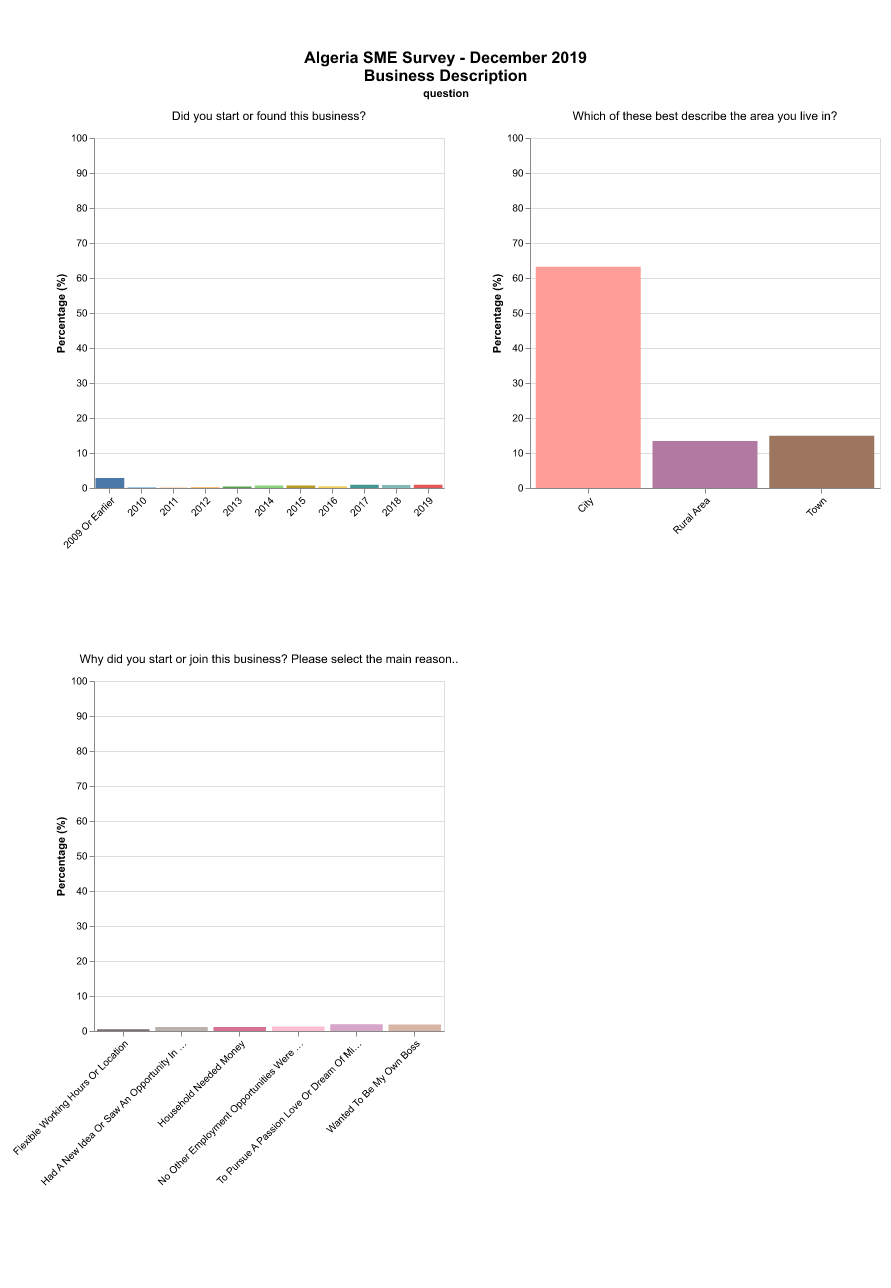

### Income

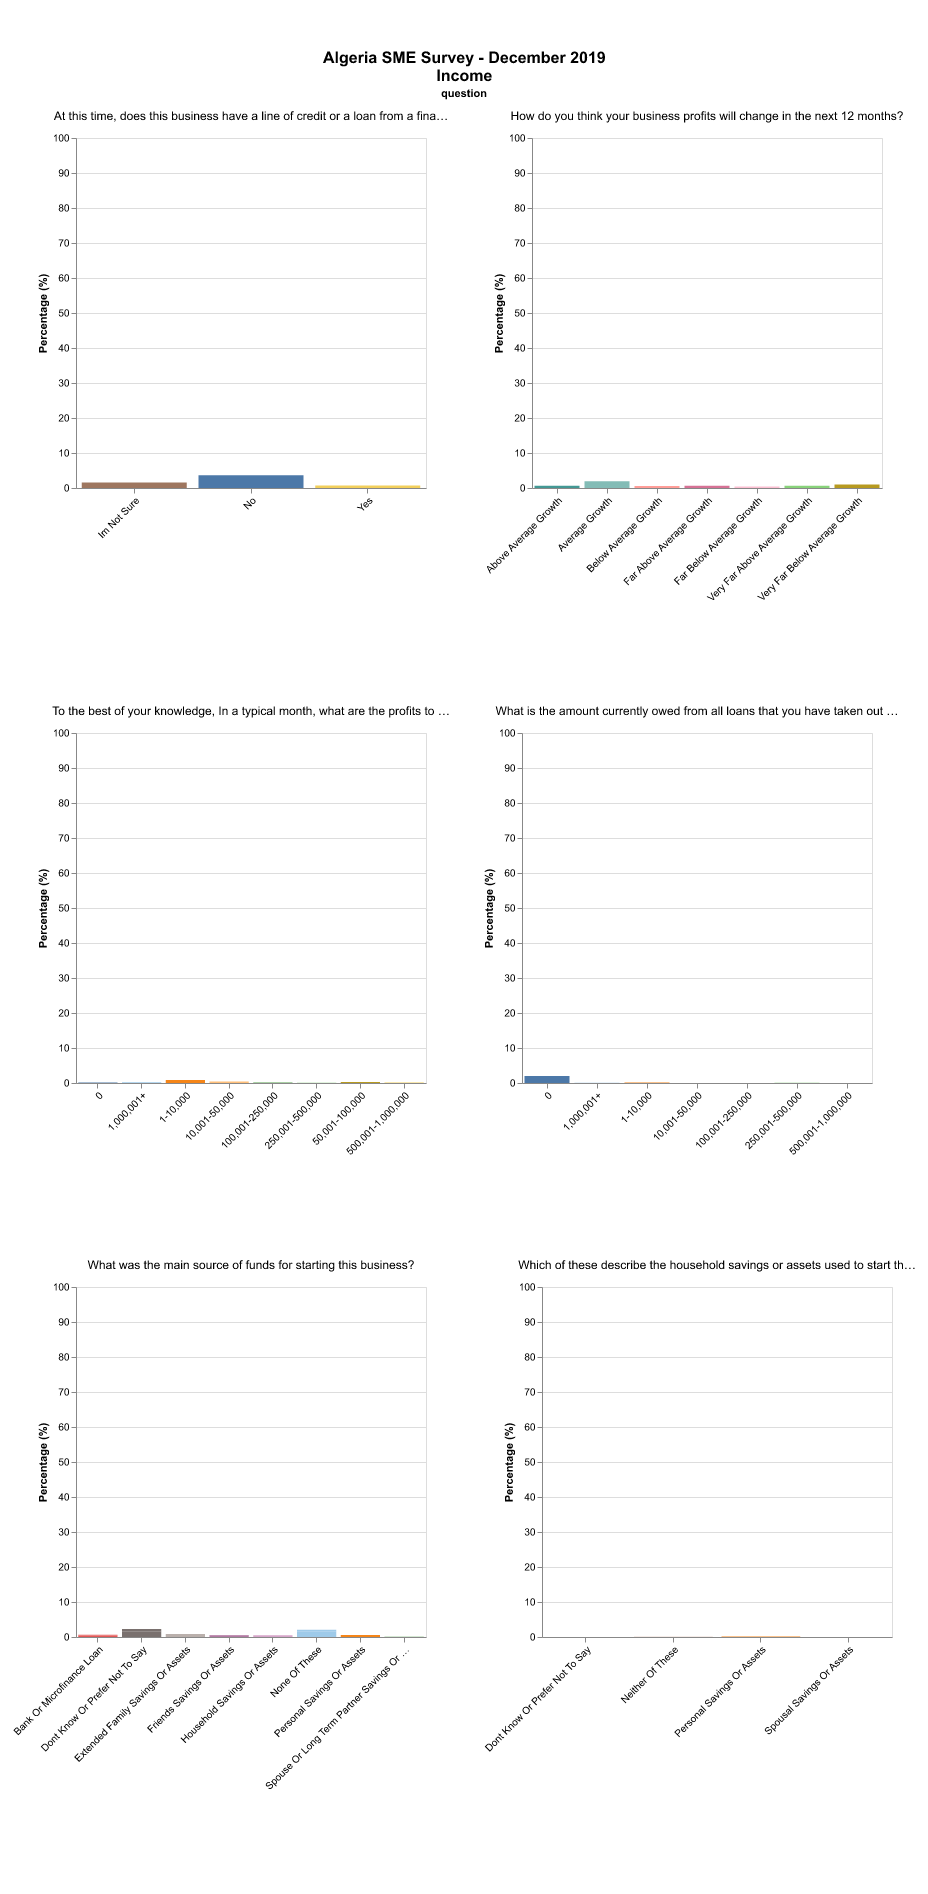

### Skills

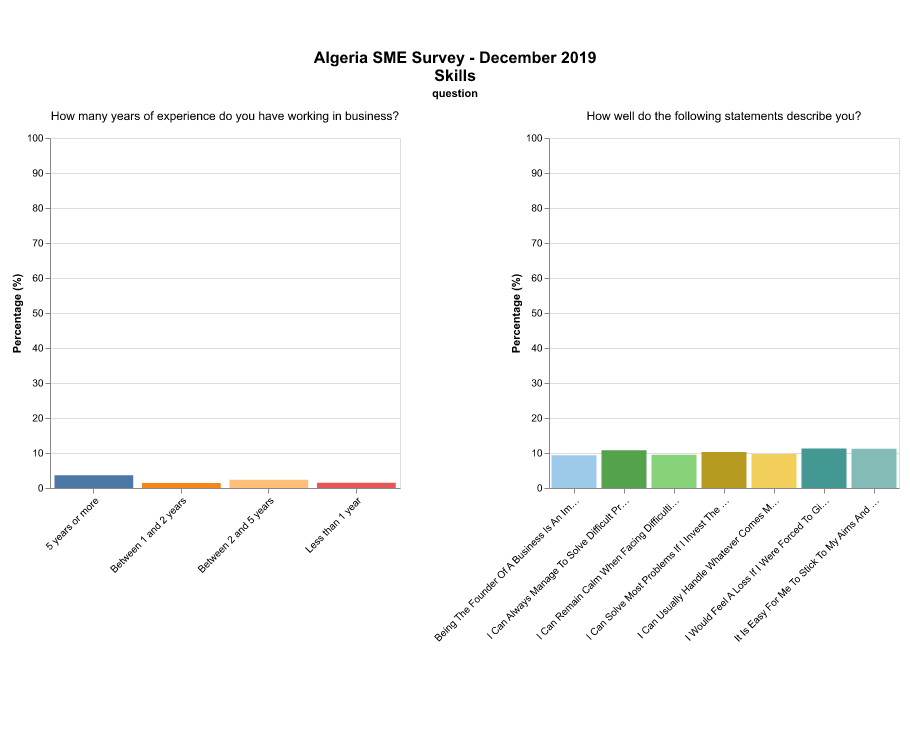

### Social Media

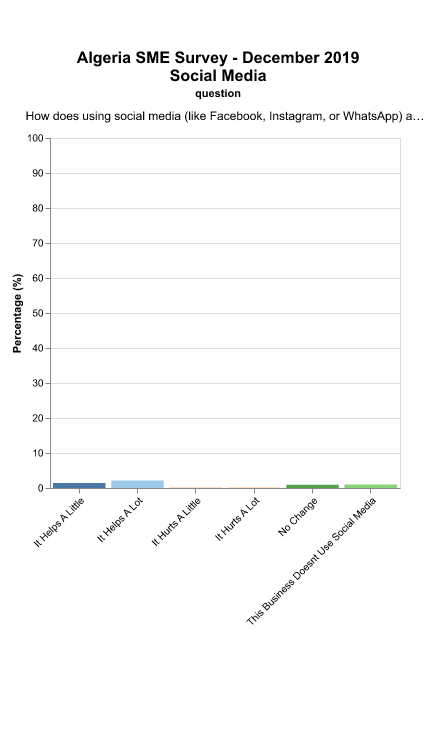

### Community

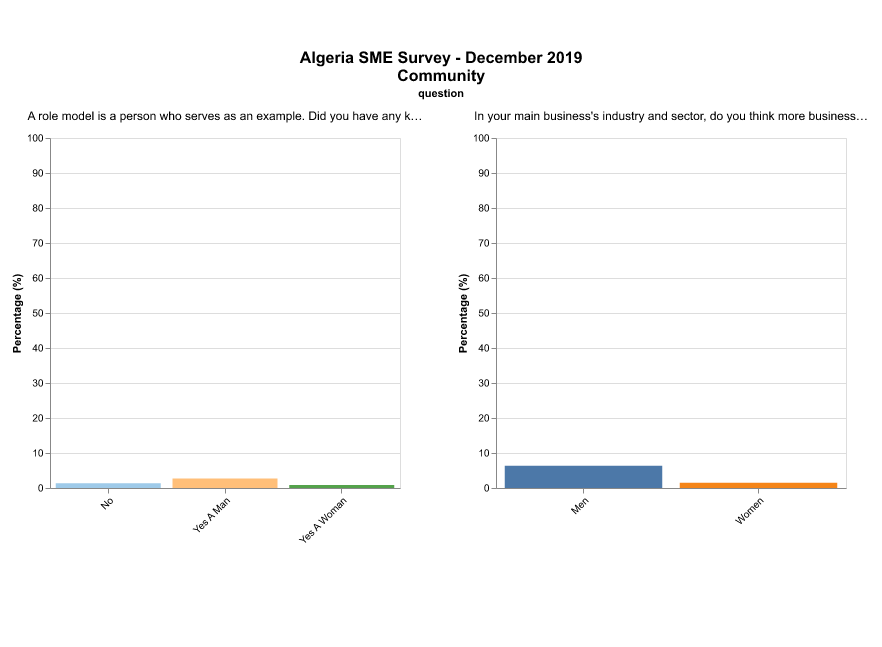

### Work Roles

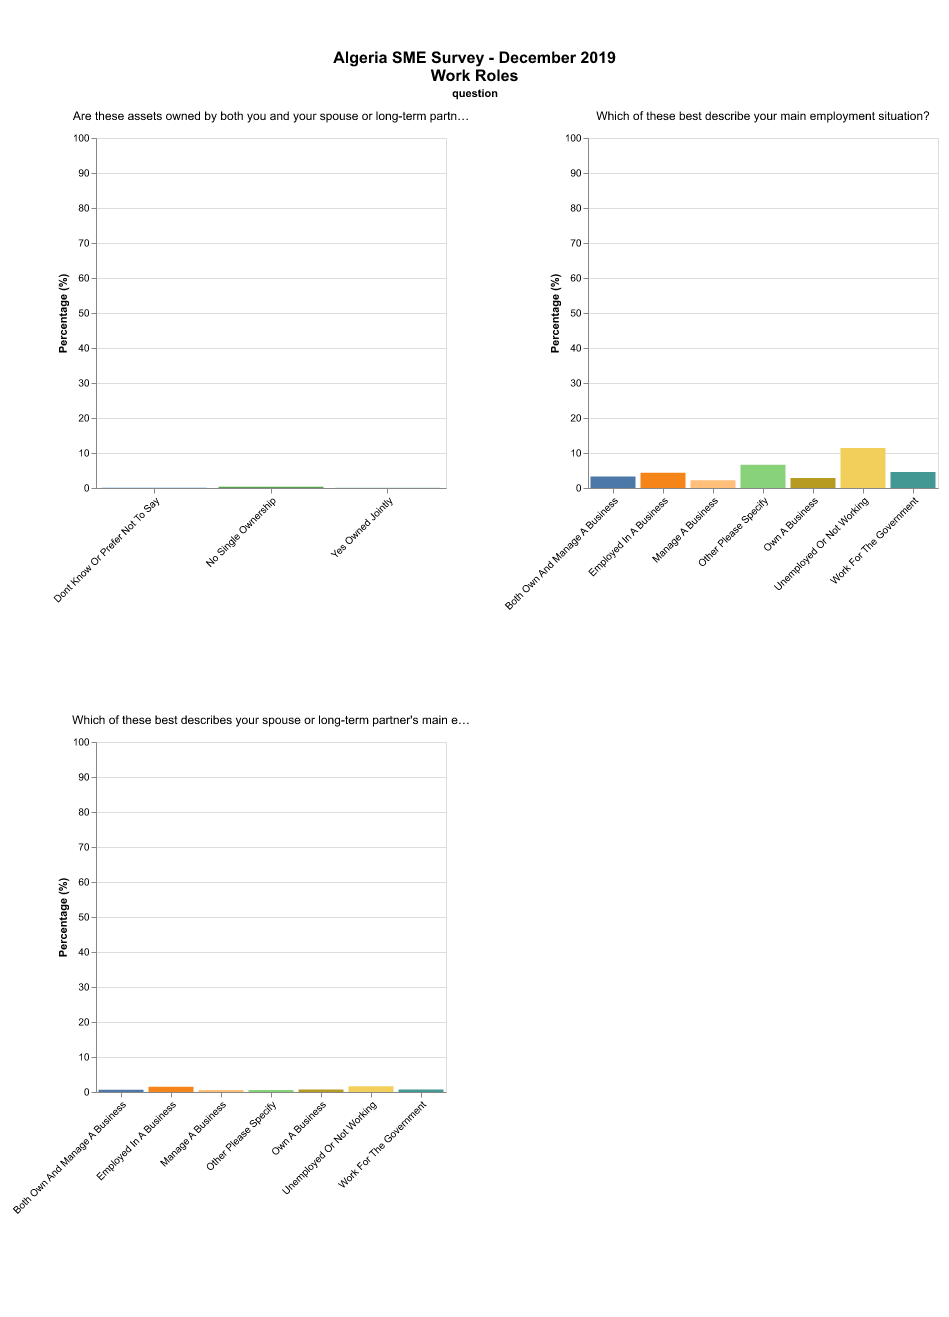

In [343]:
# Display charts by category
import os
from IPython.display import Image, display, Markdown

categories_map = {
    'Business Description': 'business_description',
    'Income': 'income',
    'Skills': 'skills',
    'Social Media': 'social_media',
    'Community': 'community',
    'Work Roles': 'work_roles'
}

for display_name, category_key in categories_map.items():
    filename = f"survey_charts_2019/{category_key}.png"
    if not os.path.exists(filename):
        print(f"No PNG found for {display_name}, skipping...")
        continue
    display(Markdown(f"### {display_name}"))
    display(Image(filename=filename))